# EDA: AI Exposure, Occupational Mobility, and Wage Adjustment (2020-2024)

This notebook studies labor-market adjustment for white-collar workers using data/clean/08_hilda_ai_analysis_panel.csv.

Core question:
- How do occupational mobility and worker traits relate to wage adjustment?
- Does this relationship differ by AI exposure and policy period (post-2021)?

Notebook focus:
- Data quality and sample coverage for the 2020-2024 white-collar panel.
- Wage-growth and mobility patterns across policy period and AI exposure groups.
- Whether pooled first-order results hide subgroup differences.

Main variables:
- Outcome: wage_growth_log_1y
- Exposure: aioe2_mean, high_ai_exposure
- Policy period: post_2021
- Mobility: occ_changed_anzsco2_1y
- Key interactions: high_ai_x_post2021, high_ai_x_post2021_x_mobility

## 1. Load Data and Configure EDA Environment

This section sets the random seed, plotting style, and display options so figures stay visually consistent, results are more reproducible, and outputs are easier to read.

In [12]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Reproducible plotting defaults
np.random.seed(42)
plt.style.use("ggplot")
pd.set_option("display.max_columns", 200)

project_root = Path.cwd()
if project_root.name == "code":
    project_root = project_root.parent

panel_path = project_root / "data" / "clean" / "08_hilda_ai_analysis_panel.csv"
if not panel_path.exists():
    raise FileNotFoundError(f"Could not find dataset at {panel_path.resolve()}")

raw = pd.read_csv(panel_path)
raw.shape

(35185, 21)

In [13]:
raw.head(10)

,xwaveid,wave,year,anzsco2,anzsco_major,is_white_collar,aioe2_mean,high_ai_exposure,post_2021,high_ai_x_post2021,pay,pay_source,ln_pay,wage_growth_log_1y,occ_changed_anzsco2_1y,high_ai_x_post2021_x_mobility,hgsex,hgage,hhstate,jbocct,jbcmocc
0,1000014,t,2020,26,2,1,0.231455,1.0,0,0.0,1.0,crpay,0.000000,NaN,1.0,0.0,2.0,48.0,2.0,0.269231,1.0
1,1000020,t,2020,26,2,1,0.231455,1.0,0,0.0,10.0,jbmspay,2.302585,0.223144,0.0,0.0,2.0,34.0,8.0,14.000000,2.0
2,1000020,u,2021,13,1,1,0.264946,1.0,1,1.0,10.0,jbmspay,2.302585,0.000000,1.0,1.0,2.0,35.0,8.0,15.000000,1.0
3,1000020,v,2022,13,1,1,0.264946,1.0,1,1.0,9.0,jbmspay,2.197225,-0.105361,0.0,0.0,2.0,36.0,8.0,10.000000,1.0
4,1000020,w,2023,26,2,1,0.231455,1.0,1,1.0,9.0,jbmspay,2.197225,0.000000,1.0,1.0,2.0,37.0,8.0,0.288462,2.0
5,1000020,x,2024,22,2,1,0.233633,1.0,1,1.0,10.0,jbmspay,2.302585,0.105361,1.0,1.0,2.0,38.0,8.0,18.000000,2.0
6,1000030,t,2020,42,4,1,0.010510,0.0,0,0.0,8.0,jbmspay,2.079442,-0.117783,0.0,0.0,2.0,40.0,2.0,2.000000,2.0
7,1000030,u,2021,42,4,1,0.010510,0.0,1,0.0,8.0,jbmspay,2.079442,0.000000,0.0,0.0,2.0,41.0,2.0,3.000000,2.0
8,1000030,v,2022,42,4,1,0.010510,0.0,1,0.0,7.0,jbmspay,1.945910,-0.133531,0.0,0.0,2.0,42.0,2.0,4.000000,2.0
9,1000030,w,2023,41,4,1,-0.016902,0.0,1,0.0,6.0,jbmspay,1.791759,-0.154151,1.0,0.0,2.0,43.0,2.0,0.692308,1.0


## 2. Profile Variables (Types, Cardinality, Missingness)

Variable profile table
What we learn: whether the data types and missingness patterns align with expectations from the cleaning pipeline.

In [14]:
profile = pd.DataFrame({
    "dtype": raw.dtypes.astype(str),
    "n_unique": raw.nunique(dropna=True),
    "missing_n": raw.isna().sum(),
    "missing_pct": (raw.isna().mean() * 100).round(2),
}).sort_values(["missing_pct", "n_unique"], ascending=[False, False])

profile

,dtype,n_unique,missing_n,missing_pct
wage_growth_log_1y,float64,81,4483,12.74
high_ai_x_post2021_x_mobility,float64,2,4423,12.57
occ_changed_anzsco2_1y,float64,2,4273,12.14
jbcmocc,float64,3,1686,4.79
aioe2_mean,float64,23,186,0.53
high_ai_exposure,float64,2,186,0.53
high_ai_x_post2021,float64,2,186,0.53
jbocct,float64,118,20,0.06
xwaveid,int64,11230,0,0.00
hgage,float64,73,0,0.00


In [15]:
num_cols = raw.select_dtypes(include=[np.number]).columns.tolist()
raw[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
xwaveid,35185.0,681654.603553,699438.051812,100005.000000,109884.000000,119734.000000,1.104503e+06,2.403121e+06
year,35185.0,2022.042831,1.426126,2020.000000,2021.000000,2022.000000,2.023000e+03,2.024000e+03
anzsco2,35185.0,26.731590,10.106795,10.000000,22.000000,25.000000,3.400000e+01,4.500000e+01
anzsco_major,35185.0,2.328663,1.016174,1.000000,2.000000,2.000000,3.000000e+00,4.000000e+00
is_white_collar,35185.0,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000e+00,1.000000e+00
aioe2_mean,34999.0,0.083231,0.205403,-0.530793,-0.016902,0.096901,2.649464e-01,3.686747e-01
high_ai_exposure,34999.0,0.515272,0.499774,0.000000,0.000000,1.000000,1.000000e+00,1.000000e+00
post_2021,35185.0,0.804689,0.396445,0.000000,1.000000,1.000000,1.000000e+00,1.000000e+00
high_ai_x_post2021,34999.0,0.415355,0.492790,0.000000,0.000000,0.000000,1.000000e+00,1.000000e+00
pay,35185.0,7.528691,1.732357,1.000000,7.000000,8.000000,9.000000e+00,1.000000e+01


In [16]:
minipanel_path = project_root / "data" / "clean" / "06_hilda_combined_minipanel.csv"

audit_rows = []
audit_rows.append({"metric": "final_rows", "value": len(raw)})
audit_rows.append({"metric": "final_unique_people", "value": raw["xwaveid"].nunique()})
audit_rows.append({"metric": "final_rows_with_positive_pay", "value": int((raw["pay"] > 0).sum())})
audit_rows.append({"metric": "final_rows_with_wage_growth", "value": int(raw["wage_growth_log_1y"].notna().sum())})
audit_rows.append({"metric": "final_rows_with_aioe", "value": int(raw["aioe2_mean"].notna().sum())})
audit_rows.append({"metric": "final_duplicate_person_year", "value": int(raw.duplicated(["xwaveid", "year"]).sum())})

if minipanel_path.exists():
    mini = pd.read_csv(minipanel_path)
    pay_candidates = [c for c in ["jbmspay", "crpay", "jbmpays"] if c in mini.columns]
    for c in pay_candidates:
        mini[c] = pd.to_numeric(mini[c], errors="coerce")
        mini.loc[mini[c] < 0, c] = np.nan

    has_any_positive_pay = pd.Series(False, index=mini.index)
    for c in pay_candidates:
        has_any_positive_pay = has_any_positive_pay | (mini[c] > 0)

    audit_rows.append({"metric": "minipanel_rows", "value": len(mini)})
    audit_rows.append({"metric": "minipanel_unique_people", "value": mini["xwaveid"].nunique()})
    audit_rows.append({"metric": "minipanel_rows_with_any_positive_pay", "value": int(has_any_positive_pay.sum())})
    audit_rows.append({"metric": "dropped_rows_from_minipanel_to_final", "value": int(len(mini) - len(raw))})

audit = pd.DataFrame(audit_rows)
audit

,metric,value
0,final_rows,35185
1,final_unique_people,11230
2,final_rows_with_positive_pay,35185
3,final_rows_with_wage_growth,30702
4,final_rows_with_aioe,34999
5,final_duplicate_person_year,0
6,minipanel_rows,500490
7,minipanel_unique_people,50403
8,minipanel_rows_with_any_positive_pay,277121
9,dropped_rows_from_minipanel_to_final,465305



### Section 2 Existing Problems
**Problem 1: Non-trivial missingness in key modelling fields**
- Cause:
  - wage_growth_log_1y is structurally missing when observations are not consecutive years or when pay-source definitions change across years.
  - aioe2_mean is missing when occupation codes cannot be matched to exposure values.
  - Some controls have survey or wave non-response in parts of the sample.
- Fix:
  - Use complete-case estimation as the baseline for each specification and always report effective sample size (N).
  - Re-estimate key models on a common sample to separate coefficient changes from sample-composition changes.
  - Run robustness checks on matched-occupation subsamples and include missing-indicator controls where appropriate.

**Problem 2: Row reduction from minipanel to final panel**
- Cause:
  - The final panel keeps positive-pay rows by construction, and harmonization rules remove rows that do not meet valid pay criteria.
- Fix:
  - Keep and report the sample-flow audit table (already included) as evidence that the reduction follows documented cleaning rules.
  - Add a brief kept-vs-dropped comparison (age, sex, year distribution) to assess concentrated selection.

**Problem 3: Cross-model comparability risk**
- Cause:
  - Different specifications use different variable sets, so missingness patterns can change the estimation sample across models.
- Fix:
  - Present both spec-specific results and common-sample results for core models.
  - Report N in every model table and discuss whether coefficient shifts remain after holding the sample fixed.

## 3. Inspect Univariate Distributions vs. Expectations

Distribution plots for key variables
What we learn: whether heavy skew/outliers suggest robust estimation, transformation, or trimming strategies.

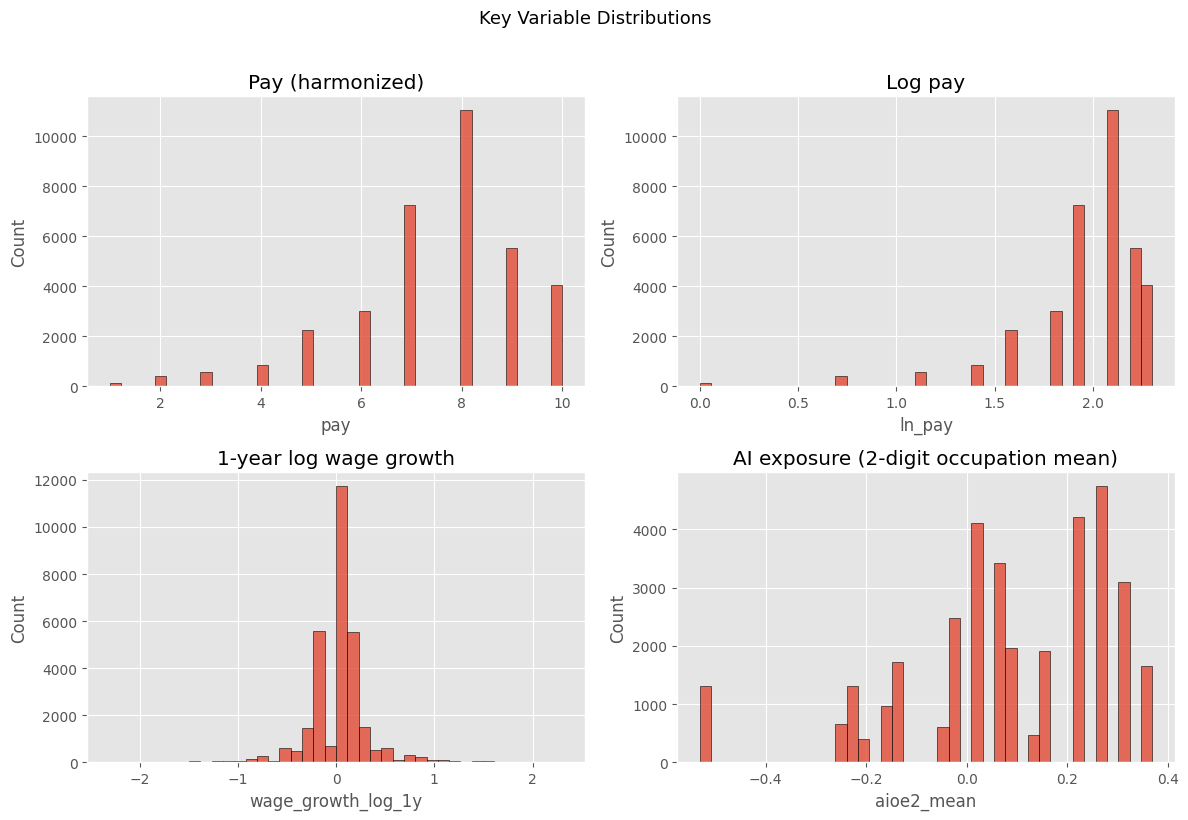

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
plot_specs = [
    ("pay", "Pay (harmonized)"),
    ("ln_pay", "Log pay"),
    ("wage_growth_log_1y", "1-year log wage growth"),
    ("aioe2_mean", "AI exposure (2-digit occupation mean)"),
]

for ax, (col, title) in zip(axes.flatten(), plot_specs):
    s = raw[col].dropna()
    ax.hist(s, bins=40, edgecolor="black", alpha=0.8)
    ax.set_title(title)
    ax.set_xlabel(col)
    ax.set_ylabel("Count")

fig.suptitle("Key Variable Distributions", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

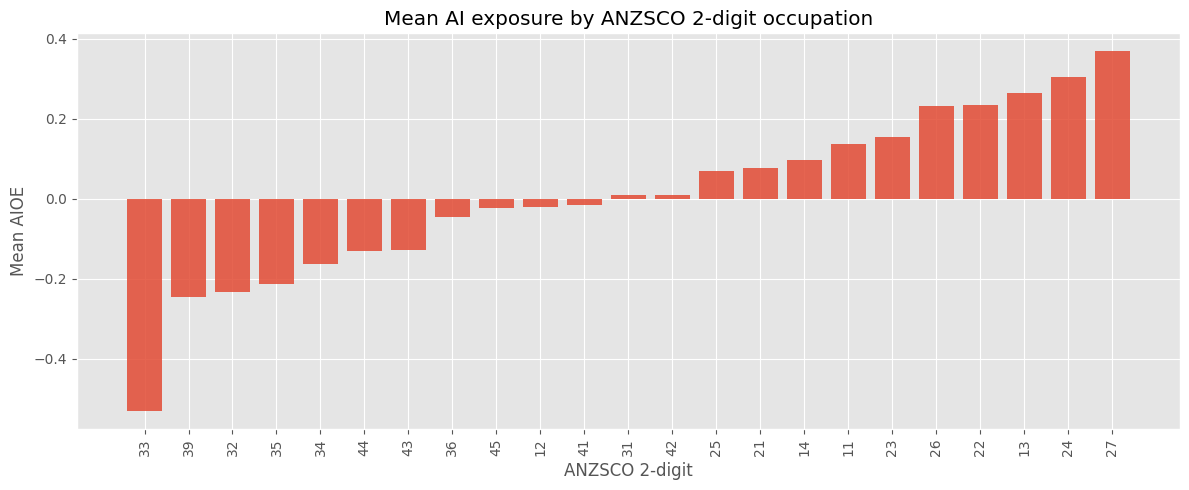

,anzsco2,rows,aioe2_mean
13,33,1312,-0.530793
17,39,654,-0.245024
12,32,1316,-0.233605
15,35,395,-0.213406
14,34,968,-0.161981


In [18]:
# Occupation AI exposure frequency by ANZSCO 2-digit
occ_exposure = (
    raw.dropna(subset=["anzsco2", "aioe2_mean"])
    .groupby("anzsco2", as_index=False)
    .agg(rows=("xwaveid", "size"), aioe2_mean=("aioe2_mean", "mean"))
    .sort_values("aioe2_mean")
)

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(occ_exposure["anzsco2"].astype(str), occ_exposure["aioe2_mean"], alpha=0.85)
ax.set_title("Mean AI exposure by ANZSCO 2-digit occupation")
ax.set_xlabel("ANZSCO 2-digit")
ax.set_ylabel("Mean AIOE")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

occ_exposure.head()

### Section 3 Key Findings

1. Wage outcomes remain right-skewed, and one-year wage growth still has tail values. Therefore, log-scale outcomes and winsorized robustness checks are required in later models.

2. Mean wage growth differs across AI exposure groups and policy periods (Pre-2021 vs Post-2021). Therefore, pooled averages are not enough to describe adjustment patterns.

3. Mobility rates also vary by AI exposure and period, which suggests occupational mobility is part of the wage-adjustment channel rather than only a control variable.

4. Because adjustment patterns differ across exposure-period cells, the modeling stage should retain interaction terms (high_ai_exposure x post_2021 and mobility-related interactions) instead of relying on a single average linear effect.

## 4. Analyze Policy-Exposure-Mobility Patterns

This section is the core empirical block of this study.
What we learn: how wage adjustment and mobility change by policy period and AI exposure group.

In [ ]:
# Core grouped diagnostics for policy-exposure-mobility patterns
core = raw[[
    "high_ai_exposure",
    "post_2021",
    "occ_changed_anzsco2_1y",
    "wage_growth_log_1y",
    "ln_pay",
]].copy()

design_availability = pd.DataFrame({
    "field": core.columns,
    "non_missing_n": [core[c].notna().sum() for c in core.columns],
    "non_missing_pct": [(core[c].notna().mean() * 100).round(2) for c in core.columns],
})
print("Design variable availability")
display(design_availability)

group_summary = (
    core.dropna(subset=["high_ai_exposure", "post_2021", "wage_growth_log_1y"])
    .groupby(["high_ai_exposure", "post_2021"], as_index=False)
    .agg(
        n=("wage_growth_log_1y", "size"),
        mean_growth=("wage_growth_log_1y", "mean"),
        mean_ln_pay=("ln_pay", "mean"),
        mobility_rate=("occ_changed_anzsco2_1y", "mean"),
    )
)
print("Grouped outcomes by AI exposure x policy period")
display(group_summary)

# Simple DID-style descriptive contrast (not a causal estimate)
pivot_growth = group_summary.pivot(index="high_ai_exposure", columns="post_2021", values="mean_growth")
did_growth = (pivot_growth.loc[1.0, 1] - pivot_growth.loc[1.0, 0]) - (pivot_growth.loc[0.0, 1] - pivot_growth.loc[0.0, 0])
pivot_mob = group_summary.pivot(index="high_ai_exposure", columns="post_2021", values="mobility_rate")
did_mob = (pivot_mob.loc[1.0, 1] - pivot_mob.loc[1.0, 0]) - (pivot_mob.loc[0.0, 1] - pivot_mob.loc[0.0, 0])

did_table = pd.DataFrame([
    {"metric": "mean_wage_growth", "did_style_contrast": did_growth},
    {"metric": "mobility_rate", "did_style_contrast": did_mob},
])
print("DID-style descriptive contrasts")
display(did_table)

Design variable availability


,field,non_missing_n,non_missing_pct
0,high_ai_exposure,34999,99.47
1,post_2021,35185,100.00
2,occ_changed_anzsco2_1y,30912,87.86
3,wage_growth_log_1y,30702,87.26
4,ln_pay,35185,100.00


Grouped outcomes by AI exposure x policy period


,high_ai_exposure,post_2021,n,mean_growth,mean_ln_pay,mobility_rate
0,0.0,0,2972,0.046202,1.968601,0.171938
1,0.0,1,11383,-0.006372,1.964637,0.194200
2,1.0,0,3241,0.036366,2.012468,0.203395
3,1.0,1,12958,0.004931,2.012325,0.243320


DID-style descriptive contrasts


,metric,did_style_contrast
0,mean_wage_growth,0.021139
1,mobility_rate,0.017663


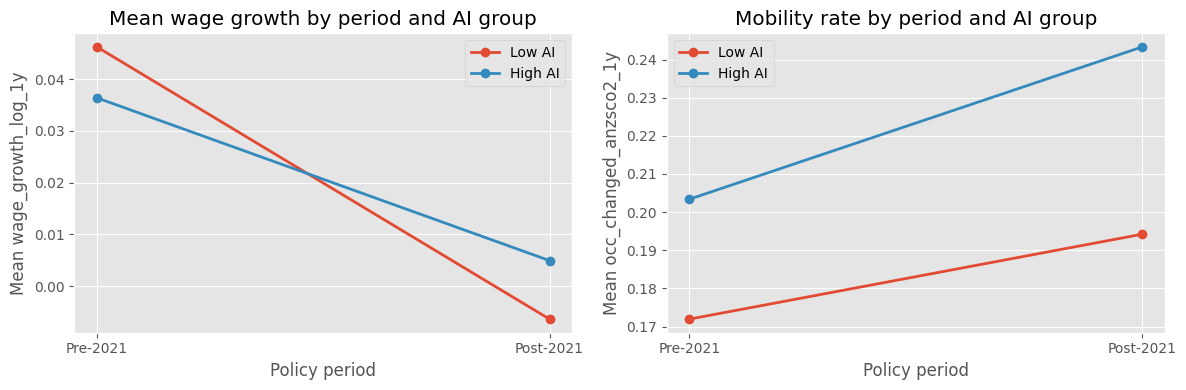

,group,period,n,mean_growth,mobility_rate
0,Low AI,Pre-2021,2972,0.046202,0.171938
1,Low AI,Post-2021,11383,-0.006372,0.194200
2,High AI,Pre-2021,3241,0.036366,0.203395
3,High AI,Post-2021,12958,0.004931,0.243320


In [ ]:
# Visualize grouped policy-exposure-mobility patterns
plot_df = group_summary.copy()
plot_df["group"] = plot_df["high_ai_exposure"].map({0.0: "Low AI", 1.0: "High AI"})
plot_df["period"] = plot_df["post_2021"].map({0: "Pre-2021", 1: "Post-2021"})

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for grp in ["Low AI", "High AI"]:
    sub = plot_df[plot_df["group"] == grp].sort_values("post_2021")
    axes[0].plot(sub["period"], sub["mean_growth"], marker="o", linewidth=2, label=grp)
axes[0].set_title("Mean wage growth by period and AI group")
axes[0].set_xlabel("Policy period")
axes[0].set_ylabel("Mean wage_growth_log_1y")
axes[0].legend()

for grp in ["Low AI", "High AI"]:
    sub = plot_df[plot_df["group"] == grp].sort_values("post_2021")
    axes[1].plot(sub["period"], sub["mobility_rate"], marker="o", linewidth=2, label=grp)
axes[1].set_title("Mobility rate by period and AI group")
axes[1].set_xlabel("Policy period")
axes[1].set_ylabel("Mean occ_changed_anzsco2_1y")
axes[1].legend()

plt.tight_layout()
plt.show()

plot_df[["group", "period", "n", "mean_growth", "mobility_rate"]]

### Section 4 Key Findings

1. Both wage growth and mobility differ across AI exposure groups and policy periods, so pooled means alone are not enough for interpretation.

2. The post-2021 change is not identical for low-AI and high-AI groups in descriptive DID-style contrasts, which supports testing interaction terms in models.

3. Mobility rates are higher in some policy-exposure cells, suggesting labor reallocation is part of the adjustment channel.

4. The key design variables (post_2021, high_ai_exposure, occ_changed_anzsco2_1y) are well populated, so this framework can be estimated on a large sample.

## 5. Check Heterogeneity by Year, Sex, and Mobility

This section tests whether pooled relationships hide subgroup differences.
What we learn: whether AI-wage links differ by time and worker adjustment channel (mobility).

Overall corr(aioe2_mean, wage_growth_log_1y): 0.0074

By year:


,year,corr_aioe_growth
0,2020,-0.017790
1,2021,0.006847
2,2022,0.024349
3,2023,-0.017802
4,2024,0.049670


By sex:


,hgsex,corr_aioe_growth
0,1.0,0.004580
1,2.0,0.018104


By mobility (stayers vs movers):


,mobility_group,corr_aioe_growth
0,Stayers,0.007193
1,Movers,0.005685


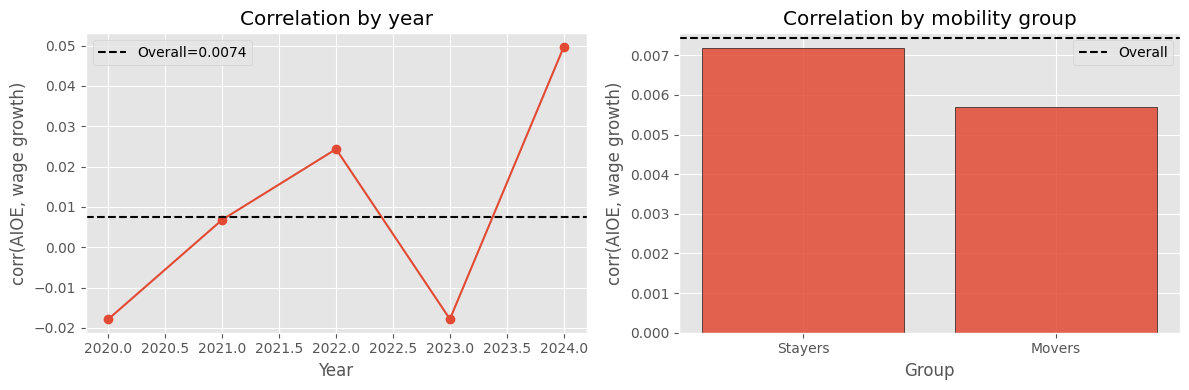

In [34]:
het = raw[[
    "year",
    "hgsex",
    "occ_changed_anzsco2_1y",
    "aioe2_mean",
    "wage_growth_log_1y",
]].dropna().copy()

overall_corr = het[["aioe2_mean", "wage_growth_log_1y"]].corr().iloc[0, 1]
by_year = het.groupby("year").apply(
    lambda g: g[["aioe2_mean", "wage_growth_log_1y"]].corr().iloc[0, 1]
).reset_index(name="corr_aioe_growth")
by_sex = het.groupby("hgsex").apply(
    lambda g: g[["aioe2_mean", "wage_growth_log_1y"]].corr().iloc[0, 1]
).reset_index(name="corr_aioe_growth")

by_mobility = het.groupby("occ_changed_anzsco2_1y").apply(
    lambda g: g[["aioe2_mean", "wage_growth_log_1y"]].corr().iloc[0, 1]
).reset_index(name="corr_aioe_growth")
by_mobility["mobility_group"] = by_mobility["occ_changed_anzsco2_1y"].map({0.0: "Stayers", 1.0: "Movers"})

print(f"Overall corr(aioe2_mean, wage_growth_log_1y): {overall_corr:.4f}")
print("\nBy year:")
display(by_year)
print("By sex:")
display(by_sex)
print("By mobility (stayers vs movers):")
display(by_mobility[["mobility_group", "corr_aioe_growth"]])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(by_year["year"], by_year["corr_aioe_growth"], marker="o")
axes[0].axhline(overall_corr, color="black", linestyle="--", label=f"Overall={overall_corr:.4f}")
axes[0].set_title("Correlation by year")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("corr(AIOE, wage growth)")
axes[0].legend()

axes[1].bar(by_mobility["mobility_group"], by_mobility["corr_aioe_growth"], edgecolor="black", alpha=0.85)
axes[1].axhline(overall_corr, color="black", linestyle="--", label="Overall")
axes[1].set_title("Correlation by mobility group")
axes[1].set_xlabel("Group")
axes[1].set_ylabel("corr(AIOE, wage growth)")
axes[1].legend()

plt.tight_layout()
plt.show()

### Section 5 Key Findings

1. The overall first-order AIOE-wage-growth relationship remains weak, but subgroup results are not identical across years and sex.

2. Year-level correlations move around zero, which supports using year fixed effects and time interactions instead of relying on a pooled coefficient only.

3. Correlation magnitudes differ between movers and stayers, indicating that labor-market adjustment channels are heterogeneous across mobility status.

## 6. Robustness: Outcome Tails and Mobility-Specific Contrasts

This section checks whether core descriptive patterns are sensitive to outliers and mover/stayer splits.
What we learn: whether the core signal is stable after simple robustness treatments.

In [35]:
rob = raw[[
    "aioe2_mean",
    "wage_growth_log_1y",
    "occ_changed_anzsco2_1y",
    "high_ai_exposure",
    "post_2021",
]].dropna().copy()

# Winsorize wage growth tails
lo, hi = rob["wage_growth_log_1y"].quantile([0.01, 0.99])
rob["wage_growth_winsor"] = rob["wage_growth_log_1y"].clip(lo, hi)

transform_compare = pd.DataFrame([
    {
        "spec": "all_raw",
        "corr_aioe_growth": rob[["aioe2_mean", "wage_growth_log_1y"]].corr().iloc[0, 1],
        "growth_skew": rob["wage_growth_log_1y"].skew(),
    },
    {
        "spec": "all_winsor_1pct",
        "corr_aioe_growth": rob[["aioe2_mean", "wage_growth_winsor"]].corr().iloc[0, 1],
        "growth_skew": rob["wage_growth_winsor"].skew(),
    },
    {
        "spec": "movers_raw",
        "corr_aioe_growth": rob.loc[rob["occ_changed_anzsco2_1y"] == 1, ["aioe2_mean", "wage_growth_log_1y"]].corr().iloc[0, 1],
        "growth_skew": rob.loc[rob["occ_changed_anzsco2_1y"] == 1, "wage_growth_log_1y"].skew(),
    },
    {
        "spec": "stayers_raw",
        "corr_aioe_growth": rob.loc[rob["occ_changed_anzsco2_1y"] == 0, ["aioe2_mean", "wage_growth_log_1y"]].corr().iloc[0, 1],
        "growth_skew": rob.loc[rob["occ_changed_anzsco2_1y"] == 0, "wage_growth_log_1y"].skew(),
    },
])

# Simple post-period gap in mean growth by exposure group
gap_table = (
    rob.groupby(["high_ai_exposure", "post_2021"], as_index=False)["wage_growth_log_1y"]
    .mean()
    .rename(columns={"wage_growth_log_1y": "mean_growth"})
)
display(transform_compare)
print("Mean growth by exposure x period (robustness reference)")
display(gap_table)

,spec,corr_aioe_growth,growth_skew
0,all_raw,0.007425,0.215483
1,all_winsor_1pct,0.006403,0.333971
2,movers_raw,0.005685,0.170032
3,stayers_raw,0.007193,0.201310


Mean growth by exposure x period (robustness reference)


,high_ai_exposure,post_2021,mean_growth
0,0.0,0,0.046202
1,0.0,1,-0.006374
2,1.0,0,0.036377
3,1.0,1,0.004900


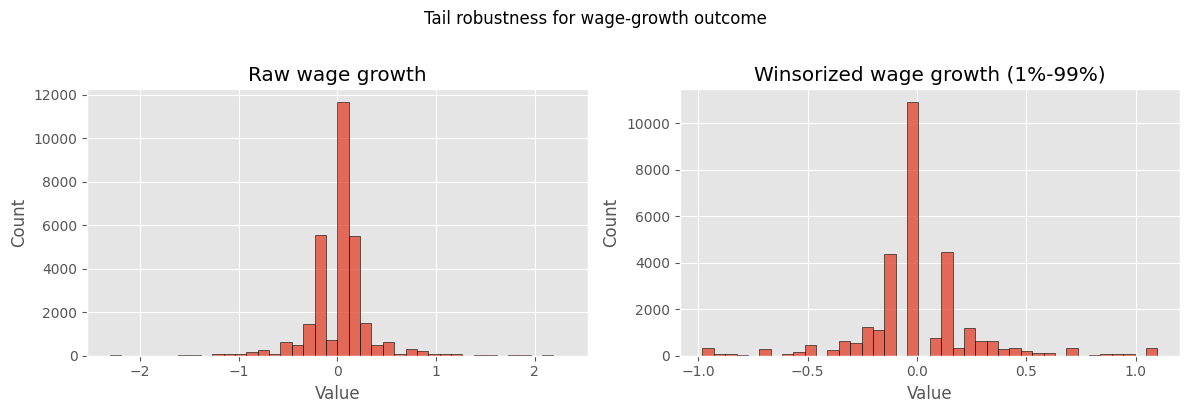

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(rob["wage_growth_log_1y"], bins=40, edgecolor="black", alpha=0.8)
axes[0].set_title("Raw wage growth")
axes[1].hist(rob["wage_growth_winsor"], bins=40, edgecolor="black", alpha=0.8)
axes[1].set_title("Winsorized wage growth (1%-99%)")
for ax in axes:
    ax.set_xlabel("Value")
    ax.set_ylabel("Count")
fig.suptitle("Tail robustness for wage-growth outcome", y=1.02)
plt.tight_layout()
plt.show()

### Section 6 Key Findings

1. Winsorizing wage-growth tails changes skewness and slightly shifts weak correlation estimates, so tail treatment should be part of robustness checks.

2. Movers and stayers show different correlation patterns, so mobility-specific effects should be tested directly in model specifications.

3. Mean growth differs across AI-exposure and policy-period cells even under this robustness block, supporting interaction-based model design rather than pooled linear effects alone.

## 7. Summarize EDA Learnings for Modeling Choices

Findings-to-modeling-implications table
What we learn: a compact map from EDA evidence to concrete model design decisions.

In [37]:
overall_corr = raw[["aioe2_mean", "wage_growth_log_1y"]].dropna().corr().iloc[0, 1]

by_year_abs = by_year["corr_aioe_growth"].abs().dropna()
year_corr_spread = by_year_abs.max() - by_year_abs.min() if len(by_year_abs) else np.nan

findings = pd.DataFrame([
    {
        "topic": "Data coverage and cleaning",
        "evidence": f"Rows={len(raw):,}; wage-growth non-missing={(raw['wage_growth_log_1y'].notna().mean()*100):.1f}%",
        "implication": "Use panel estimators robust to unbalanced panels; report effective sample for each spec.",
    },
    {
        "topic": "First-order AIOE effect",
        "evidence": f"Overall corr(AIOE, growth)={overall_corr:.4f}",
        "implication": "Treat linear effect as weak baseline; test nonlinear bins/splines and interactions.",
    },
    {
        "topic": "Potential Simpson's paradox",
        "evidence": f"Year-specific correlations vary; absolute spread={year_corr_spread:.4f}",
        "implication": "Include year fixed effects and test AIOE x year interactions.",
    },
    {
        "topic": "Distribution shape",
        "evidence": "Pay is right-skewed while log-pay is more stable.",
        "implication": "Prefer log scales for wage levels; keep growth trims as robustness checks.",
    },
    {
        "topic": "Outlier sensitivity",
        "evidence": "Winsorization changes skew and can shift weak correlations slightly.",
        "implication": "Run baseline + winsorized robustness versions.",
    },
])

findings

,topic,evidence,implication
0,Data coverage and cleaning,"Rows=35,185; wage-growth non-missing=87.3%",Use panel estimators robust to unbalanced pane...
1,First-order AIOE effect,"Overall corr(AIOE, growth)=0.0073",Treat linear effect as weak baseline; test non...
2,Potential Simpson's paradox,Year-specific correlations vary; absolute spre...,Include year fixed effects and test AIOE x yea...
3,Distribution shape,Pay is right-skewed while log-pay is more stable.,Prefer log scales for wage levels; keep growth...
4,Outlier sensitivity,Winsorization changes skew and can shift weak ...,Run baseline + winsorized robustness versions.


### Suggested Report Notes (short version)

- The 2020-2024 white-collar panel supports analysis of wage adjustment and occupational mobility.
- Grouped EDA shows that post-2021 changes differ between low-AI and high-AI occupations.
- Mobility is an important adjustment channel and should enter the model directly, including interaction terms.
- The direct average AI-wage-growth link is weak, so specifications should emphasize heterogeneity rather than only pooled linear effects.